# Rule-Based Locomotion Controller

In the previous tutorial, a central pattern generator coordinated leg phase through a coupled oscillator network. Here we use a more decentralized Walknet-style controller: each leg decides when to start a step from local coordination rules and then reuses the same `PreprogrammedSteps` trajectories to generate joint-angle and adhesion commands.

The controller implemented in `flygym.examples.locomotion.RuleBasedController` follows the first three Walknet rules:

1. A swinging leg inhibits the rostral neighboring leg from swinging.
2. A leg early in stance excites stepping in selected rostral neighbors.
3. A leg late in stance excites stepping in selected caudal and contralateral neighbors.

The original v1 tutorial summarizes these rule directions in this diagram:

<img src="https://github.com/NeLy-EPFL/_media/blob/main/flygym/rule_based_controller/rule_based.png?raw=true" alt="Walknet rule graph" width="300"/>


We first create the same v2 locomotion simulation scaffold used by the CPG tutorial: a legs-only fly with position actuators and adhesion, a tracking camera, and a flat ground world. The helper `make_locomotion_fly` keeps the model setup separate from the rule-based controller logic.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment
from flygym.compose import FlatGroundWorld
from flygym.examples.locomotion import (
    LocomotionAction,
    PreprogrammedSteps,
    RuleBasedController,
    apply_locomotion_action,
    construct_rules_graph,
    make_locomotion_fly,
)
from flygym.utils.math import Rotation3D


output_dir = Path("outputs/rule_based_controller")
output_dir.mkdir(parents=True, exist_ok=True)

fly = make_locomotion_fly(
    name="rule_demo",
    add_adhesion=True,
    colorize=True,
)
body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 1.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=30.0,
)

world = FlatGroundWorld()
spawn_pos = [0, 0, 0.5]  # FlyGym v1 default spawn z
spawn_rot = Rotation3D("quat", [1, 0, 0, 0])
world.add_fly(fly, spawn_pos, spawn_rot)

sim = Simulation(world)
renderer = sim.set_renderer([body_cam])


Next we instantiate the preprogrammed step table, the Walknet rule graph, and the rule weights. The graph maps each source leg to the target legs whose scores it changes. Rule 1 is inhibitory, so its weight is negative. Rules 2 and 3 are excitatory, and the ipsilateral and contralateral connections can use different weights.

The controller tracks three score arrays, one per rule. At every controller step it adds the rule contributions together, starts a step for the highest-scoring non-stepping leg if the score is positive, advances the phases of legs that are currently stepping, and maps those phases through `PreprogrammedSteps` to produce a `LocomotionAction`.


In [2]:
preprogrammed_steps = PreprogrammedSteps()
dof_order = fly.get_actuated_jointdofs_order("position")
rules_graph = construct_rules_graph()
weights = {
    "rule1": -10.0,
    "rule2_ipsi": 2.5,
    "rule2_contra": 1.0,
    "rule3_ipsi": 3.0,
    "rule3_contra": 2.0,
}

controller = RuleBasedController(
    timestep=sim.timestep,
    rules_graph=rules_graph,
    weights=weights,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
    seed=0,
)

print("Actuated DoFs:", len(dof_order))
print("Simulation timestep:", sim.timestep)
print(
    "Kinematic spline cycle rate (Hz):",
    round(preprogrammed_steps.step_cycle_frequency_hz, 4),
)
print("Rule weights:", weights)
for rule_name, edges_by_source in rules_graph.items():
    print(f"{rule_name}:", edges_by_source)


Actuated DoFs: 42
Simulation timestep: 0.0001
Kinematic spline cycle rate (Hz): 7.4074
Rule weights: {'rule1': -10.0, 'rule2_ipsi': 2.5, 'rule2_contra': 1.0, 'rule3_ipsi': 3.0, 'rule3_contra': 2.0}
rule1: {'lm': ('lf',), 'lh': ('lm',), 'rm': ('rf',), 'rh': ('rm',)}
rule2: {'lf': ('rf',), 'lm': ('rm', 'lf'), 'lh': ('rh', 'lm'), 'rf': ('lf',), 'rm': ('lm', 'rf'), 'rh': ('lh', 'rm')}
rule3: {'lf': ('rf', 'lm'), 'lm': ('rm', 'lh'), 'lh': ('rh',), 'rf': ('lf', 'rm'), 'rm': ('lm', 'rh'), 'rh': ('lh',)}


Before coupling the controller to MuJoCo, we can run the coordinator by itself and inspect the internal scores. This is useful because the rule-based controller is event-like: a leg at phase zero is waiting in stance, while a leg with phase between zero and `2π` is progressing through a preprogrammed step. Positive combined scores trigger new steps, and the score traces show which rule is responsible for each transition.


In [3]:
diagnostic_run_time = 1.0
diagnostic_steps = int(diagnostic_run_time / sim.timestep)
diagnostic_controller = RuleBasedController(
    timestep=sim.timestep,
    rules_graph=rules_graph,
    weights=weights,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
    seed=0,
)

score_hist_overall = np.full((diagnostic_steps, 6), np.nan, dtype=np.float32)
score_hist_rule1 = np.full((diagnostic_steps, 6), np.nan, dtype=np.float32)
score_hist_rule2 = np.full((diagnostic_steps, 6), np.nan, dtype=np.float32)
score_hist_rule3 = np.full((diagnostic_steps, 6), np.nan, dtype=np.float32)
leg_phases_hist = np.full((diagnostic_steps, 6), np.nan, dtype=np.float32)
for step_idx in range(diagnostic_steps):
    diagnostic_controller.step()
    score_hist_overall[step_idx] = diagnostic_controller.combined_scores
    score_hist_rule1[step_idx] = diagnostic_controller.rule1_scores
    score_hist_rule2[step_idx] = diagnostic_controller.rule2_scores
    score_hist_rule3[step_idx] = diagnostic_controller.rule3_scores
    leg_phases_hist[step_idx] = diagnostic_controller.leg_phases % (2 * np.pi)


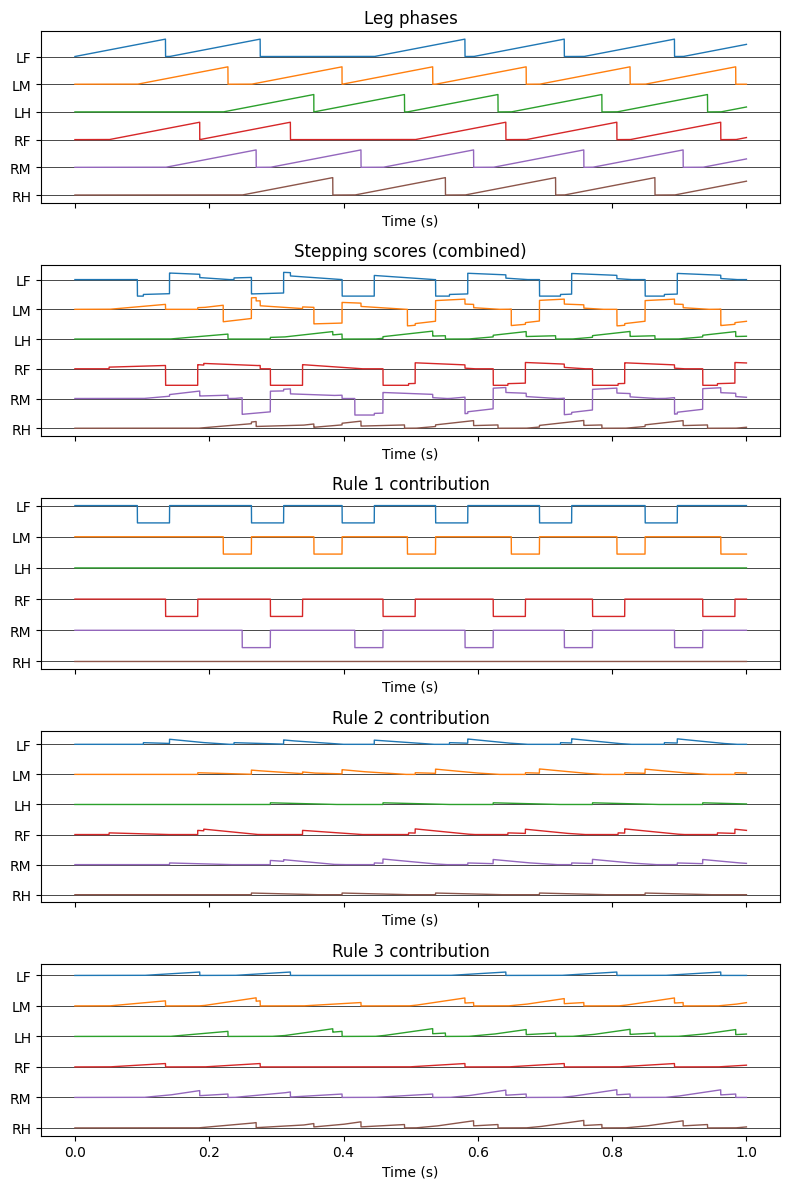

In [4]:
def plot_time_series_multi_legs(
    time_series_block,
    timestep,
    spacing=10,
    legs=RuleBasedController.legs,
    ax=None,
):
    t_grid = np.arange(time_series_block.shape[0]) * timestep
    spacing *= -1
    offset = np.arange(len(legs))[np.newaxis, :] * spacing
    trace_block = time_series_block + offset
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
    for leg_idx, leg in enumerate(legs):
        ax.axhline(offset.ravel()[leg_idx], color="k", linewidth=0.5)
        ax.plot(t_grid, trace_block[:, leg_idx], linewidth=1)
    ax.set_yticks(offset.ravel(), [leg.upper() for leg in legs])
    ax.set_xlabel("Time (s)")
    return ax


fig, axs = plt.subplots(5, 1, figsize=(8, 12), tight_layout=True, sharex=True)

plot_time_series_multi_legs(leg_phases_hist, timestep=sim.timestep, ax=axs[0])
axs[0].set_title("Leg phases")

plot_time_series_multi_legs(
    score_hist_overall,
    timestep=sim.timestep,
    spacing=18,
    ax=axs[1],
)
axs[1].set_title("Stepping scores (combined)")

plot_time_series_multi_legs(score_hist_rule1, timestep=sim.timestep, spacing=18, ax=axs[2])
axs[2].set_title("Rule 1 contribution")

plot_time_series_multi_legs(score_hist_rule2, timestep=sim.timestep, spacing=18, ax=axs[3])
axs[3].set_title("Rule 2 contribution")

plot_time_series_multi_legs(score_hist_rule3, timestep=sim.timestep, spacing=18, ax=axs[4])
axs[4].set_title("Rule 3 contribution")

fig.savefig(output_dir / "rule_based_control_signals.png")


Now we reset the physics simulation, put the legs in the default preprogrammed pose, turn adhesion on, and let the body settle. After that, the same `RuleBasedController.step()` call returns the joint-angle and adhesion commands that are applied to the fly.


In [5]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)
apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()


During the rollout we record thorax position, controller phase, combined score, and adhesion state. Rendering is handled through `render_as_needed_with_profile`, so frames are buffered at the renderer's output frame rate rather than on every MuJoCo timestep.


In [6]:
run_time = 2.0
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(BodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
rule_phases = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
combined_scores = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
adhesion_onoff = np.zeros((nsteps_sim, 6), dtype=bool)

for step_idx in trange(nsteps_sim, desc="Running rule-based controller"):
    action = controller.step()
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    rule_phases[step_idx] = controller.leg_phases % (2 * np.pi)
    combined_scores[step_idx] = controller.combined_scores
    adhesion_onoff[step_idx] = action.adhesion_onoff

    sim.render_as_needed_with_profile()

print(
    "Rendered frames (body_cam):",
    len(renderer.frames[body_cam.full_identifier]),
)
print(
    "Thorax forward displacement (first to last sample, sim):",
    f"{thorax_positions[-1, 0] - thorax_positions[0, 0]:.2f} mm",
)
sim.print_performance_report()


Running rule-based controller: 100%|██████████| 20000/20000 [00:17<00:00, 1153.90it/s]

Rendered frames (body_cam): 248
Thorax forward displacement (first to last sample, sim): 13.51 mm
PERFORMANCE PROFILE


Stage,Time/step (us),Percent (%),Throughput (iters/s),Throughput x realtime
Physics simulation advancement,73,12,13772,1.38
Rendering*,539,88,1855,0.19
TOTAL,612,100,1635,0.16


* Note: 248 frames were rendered out of 20000 steps. Therefore, rendering time per image is 43470 us.


Display the rendered rule-based walking rollout and save a copy under `outputs/rule_based_controller`.


In [7]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "rule_based_controller.mp4")


rule_demo/body_cam This browser does not support the video tag.


Finally, we can plot a compact set of rollout diagnostics. The controller phase traces show when each leg is actively stepping; the adhesion raster shows when each leg is attached to the ground.


Text(0.5, 1.0, 'Adhesion state')

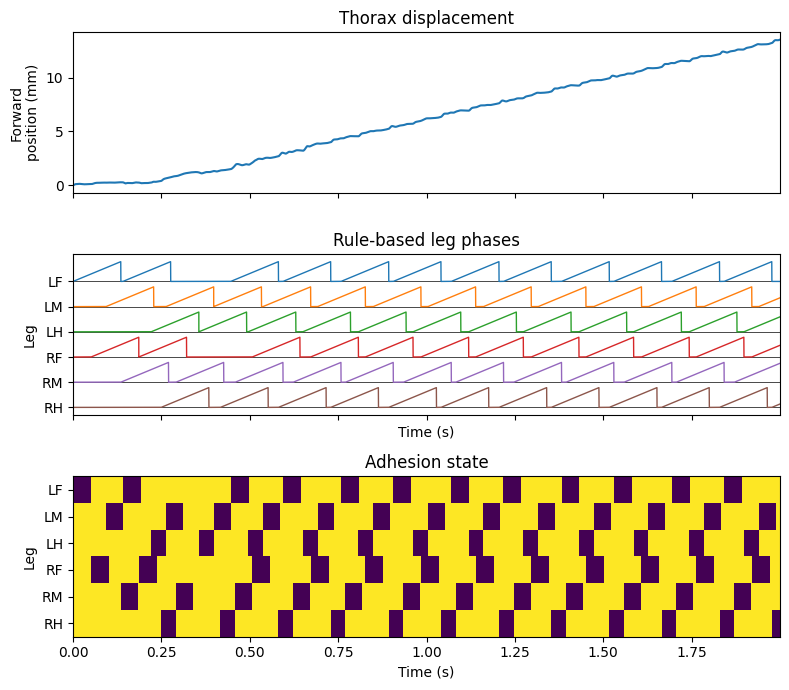

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), tight_layout=True, sharex=True)

axes[0].plot(time_grid, thorax_positions[:, 0] - thorax_positions[0, 0])
axes[0].set_ylabel("Forward\nposition (mm)")
axes[0].set_title("Thorax displacement")

plot_time_series_multi_legs(rule_phases, timestep=sim.timestep, spacing=8, ax=axes[1])
axes[1].set_ylabel("Leg")
axes[1].set_title("Rule-based leg phases")

axes[2].imshow(
    adhesion_onoff.T,
    aspect="auto",
    interpolation="nearest",
    extent=(time_grid[0], time_grid[-1], 5.5, -0.5),
)
axes[2].set_yticks(np.arange(6))
axes[2].set_yticklabels([leg.upper() for leg in preprogrammed_steps.legs])
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Leg")
axes[2].set_title("Adhesion state")
